In [ ]:
from keras.utils import to_categorical
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input
from keras.optimizers import Adam
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import os
from keras.utils import load_img, img_to_array
from tqdm import tqdm
import cv2

2025-12-02 10:28:01.199075: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764671281.389029      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764671281.440859      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [ ]:
train_dr = '/kaggle/input/ucf-crime-dataset/Train'
test_dr = '/kaggle/input/ucf-crime-dataset/Test'

In [ ]:
def createdataframe(dir):
  image_path =[]
  labels = []
  for label in os.listdir(dir):
    for image in os.listdir(os.path.join(dir,label)):
      image_path.append(os.path.join(dir,label,image))
      labels.append(label)
    print(label,"Completed")
  return image_path,labels


In [ ]:
train = pd.DataFrame()
train['image'], train['labels'] = createdataframe(train_dr)

RoadAccidents Completed
Assault Completed
Vandalism Completed
Arrest Completed
Shooting Completed
NormalVideos Completed
Arson Completed
Explosion Completed
Shoplifting Completed
Robbery Completed
Stealing Completed
Burglary Completed
Abuse Completed
Fighting Completed


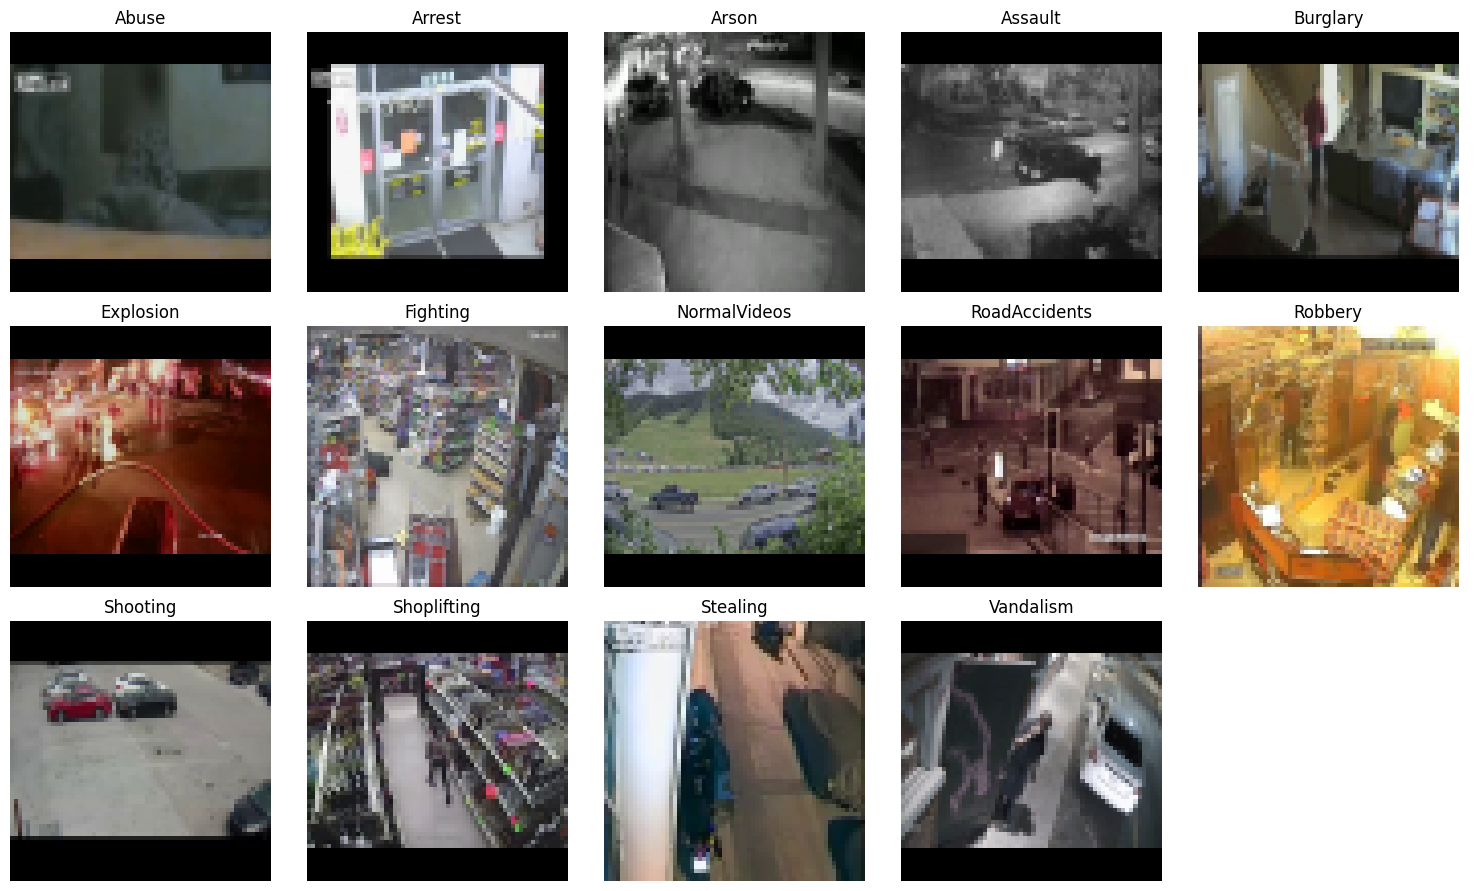

In [ ]:
def show_class_images(train_df, num_images_per_class=1):
    classes = sorted(train_df['labels'].unique())
    num_columns = min(len(classes), 5)
    num_rows = (len(classes) + num_columns - 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 3, num_rows * 3))
    axes = axes.flatten()

    for i, class_name in enumerate(classes):
        img_path = train_df[train_df['labels'] == class_name]['image'].iloc[0]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img)
        axes[i].set_title(class_name)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

show_class_images(train)

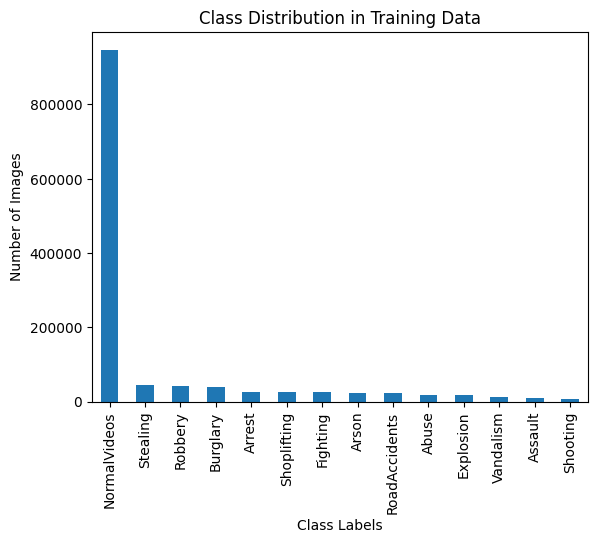

In [ ]:
train['labels'].value_counts().plot(kind='bar')
plt.title('Class Distribution in Training Data')
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.show()

In [ ]:
test = pd.DataFrame()
test['image'], test['labels'] = createdataframe(test_dr)

RoadAccidents Completed
Assault Completed
Vandalism Completed
Arrest Completed
Shooting Completed
NormalVideos Completed
Arson Completed
Explosion Completed
Shoplifting Completed
Robbery Completed
Stealing Completed
Burglary Completed
Abuse Completed
Fighting Completed


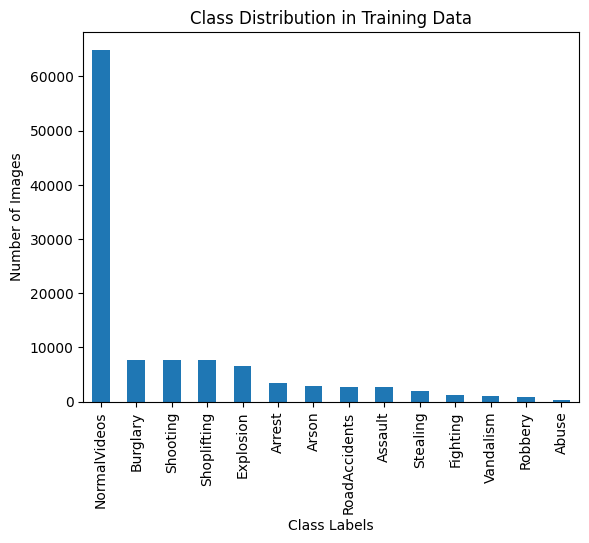

In [ ]:
test['labels'].value_counts().plot(kind='bar')
plt.title('Class Distribution in Training Data')
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.show()

In [ ]:

def remove_labels(df):
    labels_to_remove = ['Robbery', 'Vandalism', 'RoadAccidents', 'Arson', 'Arrest']
    df_filtered = df[~df['labels'].isin(labels_to_remove)]
    return df_filtered

train = remove_labels(train)
test = remove_labels(test)

print(train['labels'].value_counts())
print(test['labels'].value_counts())

labels
NormalVideos    947768
Stealing         44802
Burglary         39504
Shoplifting      24835
Fighting         24684
Abuse            19076
Explosion        18753
Assault          10360
Shooting          7140
Name: count, dtype: int64
labels
NormalVideos    64952
Burglary         7657
Shooting         7630
Shoplifting      7623
Explosion        6510
Assault          2657
Stealing         1984
Fighting         1231
Abuse             297
Name: count, dtype: int64


In [ ]:

# Desired counts
train_normal_count = 50000

# Separate the majority class
train_majority = train[train['labels'] == 'NormalVideos']
train_minority = train[train['labels'] != 'NormalVideos']

# Downsample the majority class
train_majority_downsampled = train_majority.sample(
    n=train_normal_count, random_state=42
)

# Combine with minority classes
train_balanced = pd.concat([train_majority_downsampled, train_minority])

# Shuffle the dataset
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced Train Class Distribution:")
print(train_balanced['labels'].value_counts())


Balanced Train Class Distribution:
labels
NormalVideos    50000
Stealing        44802
Burglary        39504
Shoplifting     24835
Fighting        24684
Abuse           19076
Explosion       18753
Assault         10360
Shooting         7140
Name: count, dtype: int64


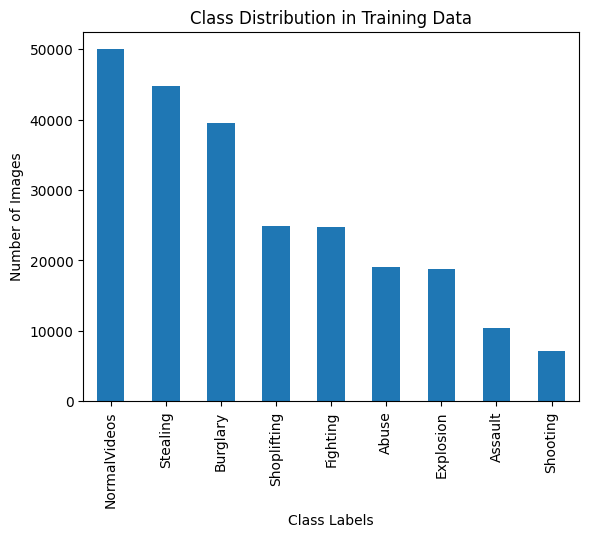

In [ ]:
train_balanced['labels'].value_counts().plot(kind='bar')
plt.title('Class Distribution in Training Data')
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.show()

In [ ]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image, color_mode='rgb', target_size=(48, 48))  # RGB mode
        img_array = img_to_array(img)
        features.append(img_array)

    features = np.array(features)
    features = features.reshape(len(features), 48, 48, 3)  # 3 channels now
    return features

In [ ]:
train_features = extract_features(train_balanced['image'])

100%|██████████| 239154/239154 [06:43<00:00, 592.69it/s]


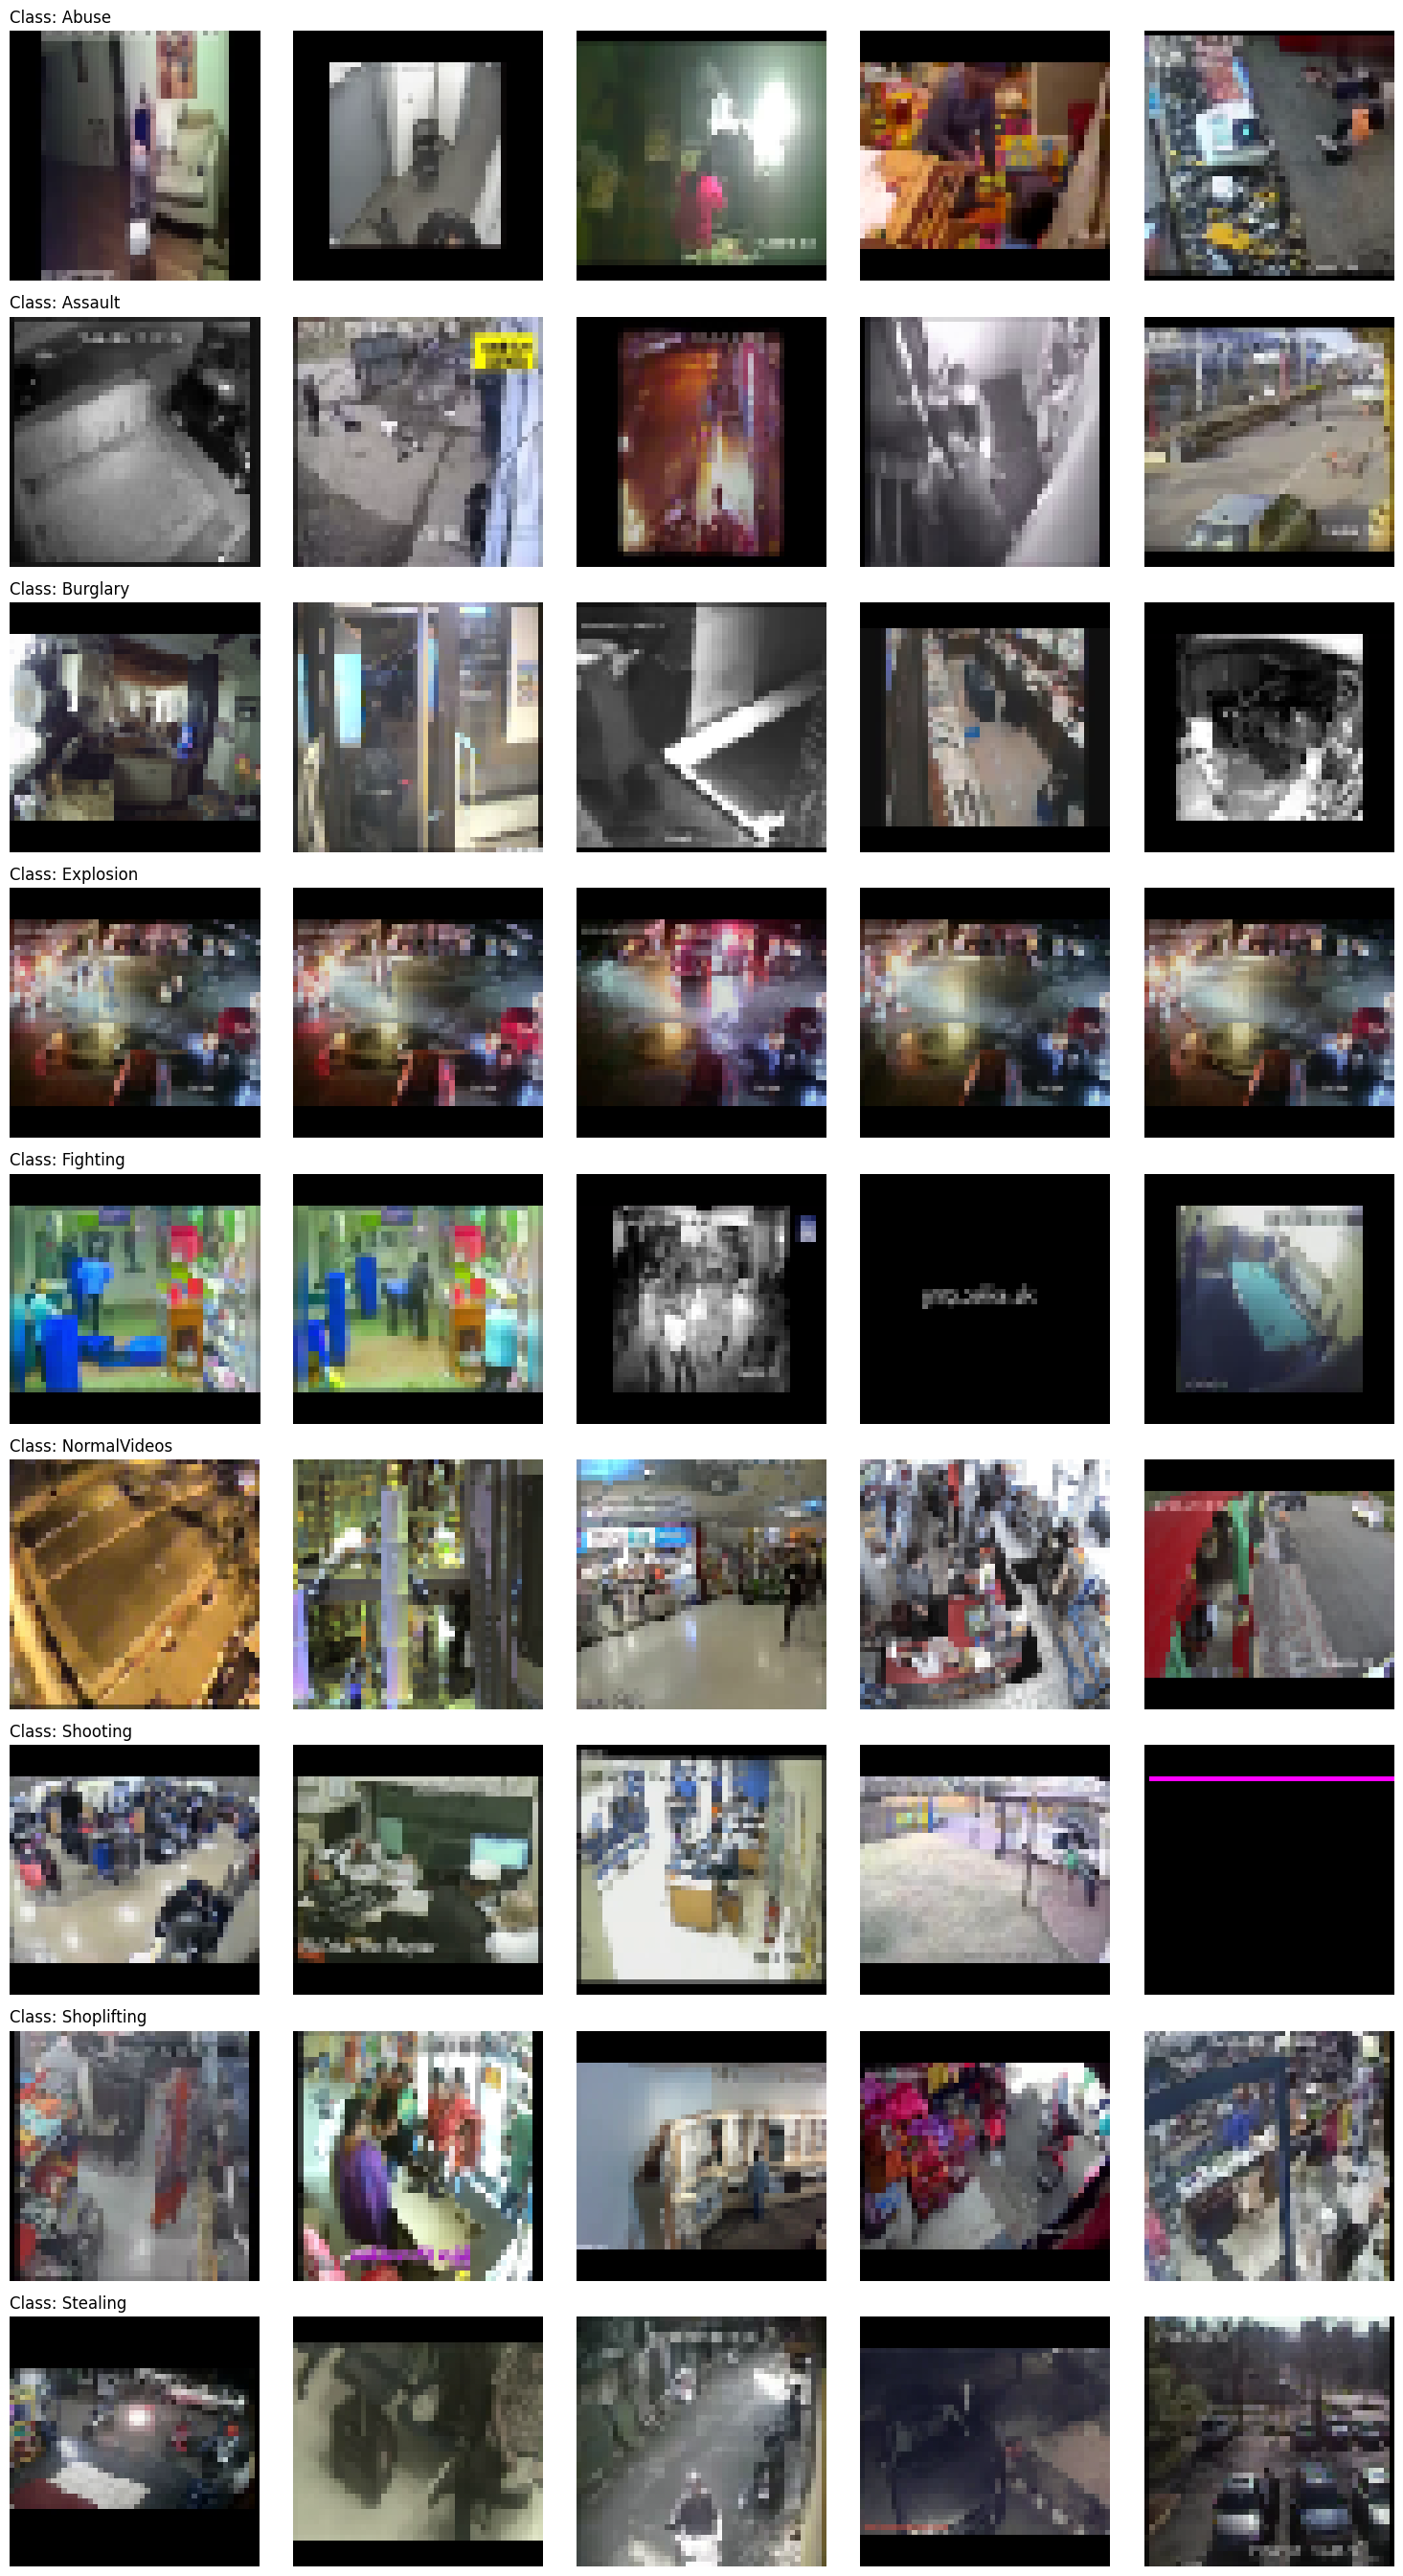

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

unique_classes = np.unique(train_balanced['labels'])
cols = 5
rows = len(unique_classes)

fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
# If only 1 row or 1 col, axes might not be a 2D array; ensure it is
if rows == 1:
    axes = np.expand_dims(axes, axis=0)
if cols == 1:
    axes = np.expand_dims(axes, axis=1)

# Make sure train_features is a numpy array
train_features = np.array(train_features)

for r, class_label in enumerate(unique_classes):
    class_df = train_balanced[train_balanced['labels'] == class_label]
    n_show = min(cols, len(class_df))

    # select first n_show rows for this class
    selected = class_df.iloc[:n_show]

    for c in range(cols):
        ax = axes[r, c]
        ax.axis('off')

        if c < n_show:
            img_index = selected.index[c]  # DataFrame index -> corresponds to your train_features index
            img = train_features[img_index]

            # If flattened vector, reshape
            if img.ndim == 1:
                if img.size == 48*48:
                    img = img.reshape(48, 48)
                elif img.size == 48*48*3:
                    img = img.reshape(48, 48, 3)
                else:
                    raise ValueError(f"Unexpected flattened image size: {img.size}")

            # If grayscale shaped (48,48)
            if img.ndim == 2:
                ax.imshow(img, cmap='gray')
            # If RGB shaped (48,48,3)
            elif img.ndim == 3 and img.shape[2] == 3:
                # If floats in [0,1], scale to [0,255] for nicer display (imshow handles both but ensure dtype)
                if img.dtype != np.uint8:
                    disp = img
                    # if floats between 0..1, keep them, else normalize for visualization
                    if disp.max() <= 1.0:
                        ax.imshow(disp)
                    else:
                        ax.imshow(np.clip(disp,0,255).astype(np.uint8))
                else:
                    ax.imshow(img)
            else:
                # other unexpected shapes
                ax.text(0.5,0.5, "Bad shape\n" + str(img.shape), ha='center')
        else:
            # empty slot (no image)
            ax.set_visible(False)

    # Title on the left-most subplot of the row
    axes[r, 0].set_title(f'Class: {class_label}', loc='left', fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
test_features = extract_features(test['image'])

100%|██████████| 100541/100541 [02:50<00:00, 588.05it/s]


In [ ]:
features = train_features/255.0

In [ ]:
labels = train_balanced['labels']

In [ ]:
le = LabelEncoder()
labels = le.fit_transform(labels)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

## LSTM + CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(Input(shape=(48, 48, 3)))   # <- RGB (3 channels) instead of 1

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(9, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,332,169 (24.16 MB)

 Trainable params: 6,332,169 (24.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=5,
    validation_data=(X_test, y_test)
)

In [ ]:

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

1495/1495 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9850 - loss: 0.0625
Test Loss: 0.06380902230739594, Test Accuracy: 0.9843407273292542


In [ ]:

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

# Predict on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)


report = classification_report(y_test, y_pred_classes, target_names=le.classes_)
print("Classification Report:\n", report)


1495/1495 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9850 - loss: 0.0625
Test Loss: 0.06380902230739594, Test Accuracy: 0.9843407273292542
1495/1495 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step
Classification Report:
               precision    recall  f1-score   support

       Abuse       0.99      0.97      0.98      3902
     Assault       1.00      0.96      0.98      2044
    Burglary       1.00      0.99      0.99      8025
   Explosion       1.00      0.97      0.98      3753
    Fighting       0.99      0.97      0.98      4959
NormalVideos       0.95      0.99      0.97     10028
    Shooting       0.99      0.98      0.98      1432
 Shoplifting       1.00      1.00      1.00      4992
    Stealing       1.00      1.00      1.00      8696

    accuracy                           0.98     47831
   macro avg       0.99      0.98      0.98     47831
weighted avg       0.98      0.98      0.98     47831



In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Convert y_test if it is one-hot
if y_test.ndim > 1:
    y_true = y_test.argmax(axis=1)
else:
    y_true = y_test

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


NameError: name 'class_names' is not defined

<Figure size 700x600 with 0 Axes>

Classes: ['Abuse', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'NormalVideos', 'Shooting', 'Shoplifting', 'Stealing']


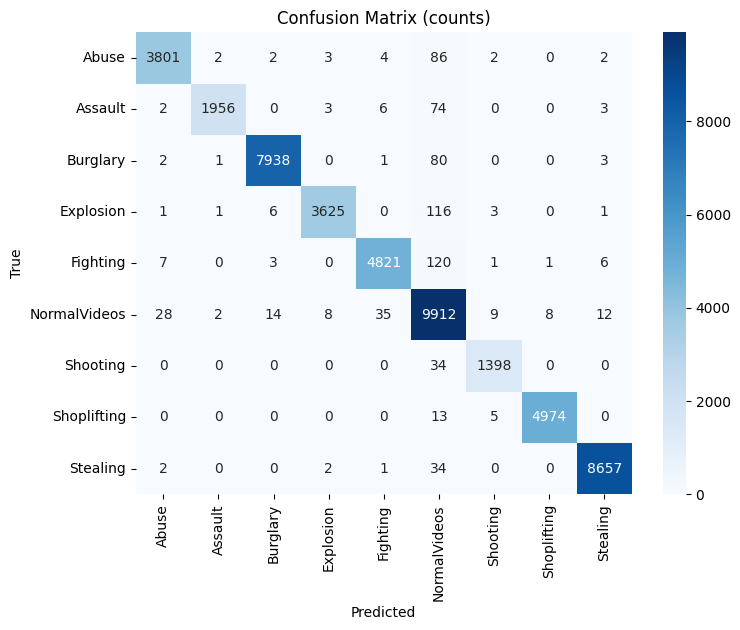

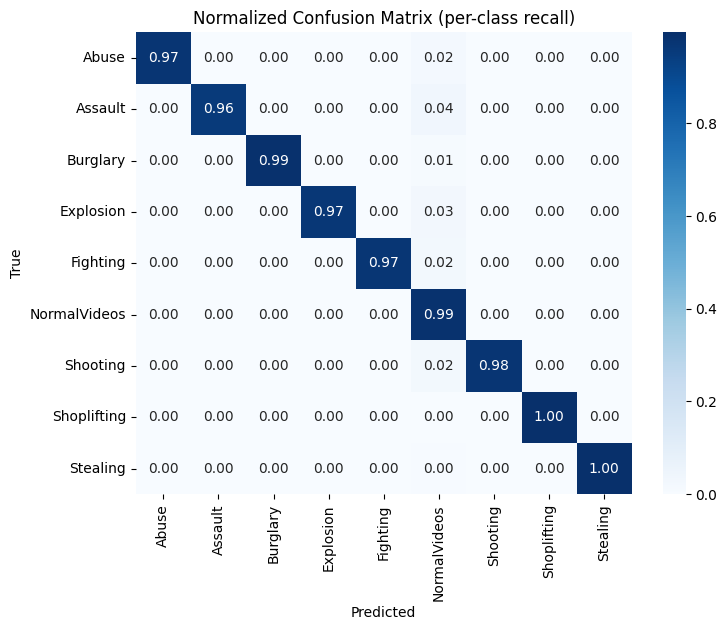

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


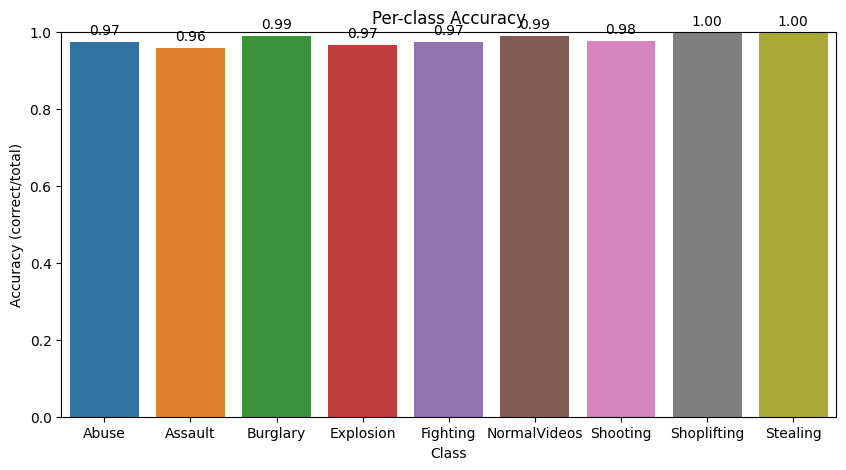

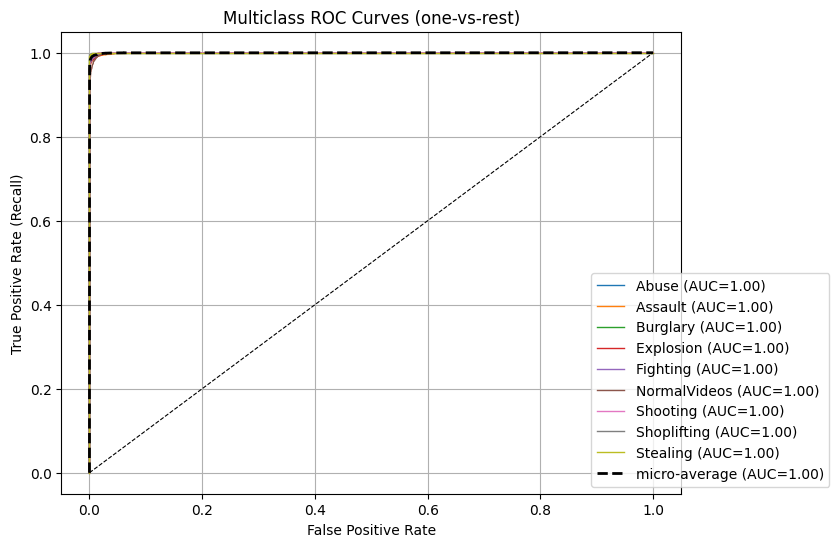

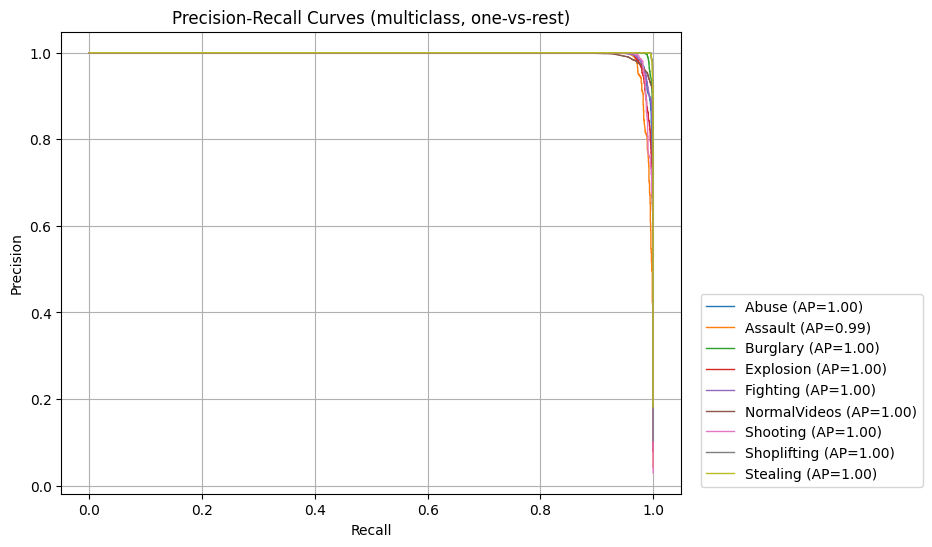

Classification report (from sklearn):

              precision    recall  f1-score   support

       Abuse     0.9891    0.9741    0.9815      3902
     Assault     0.9969    0.9569    0.9765      2044
    Burglary     0.9969    0.9892    0.9930      8025
   Explosion     0.9956    0.9659    0.9805      3753
    Fighting     0.9903    0.9722    0.9812      4959
NormalVideos     0.9468    0.9884    0.9672     10028
    Shooting     0.9859    0.9763    0.9811      1432
 Shoplifting     0.9982    0.9964    0.9973      4992
    Stealing     0.9969    0.9955    0.9962      8696

    accuracy                         0.9843     47831
   macro avg     0.9885    0.9794    0.9838     47831
weighted avg     0.9848    0.9843    0.9844     47831

Overall accuracy: 0.9843


In [ ]:
# ---- Plots: confusion matrices, ROC, PR, per-class accuracy ----
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report
)
from sklearn.preprocessing import label_binarize

# --- Helper: normalize inputs to integer labels and prediction probs/labels
def normalize_inputs(y_test, y_pred):
    """
    Returns:
      y_true_int: shape (n,) integer labels
      y_score: shape (n, n_classes) float probabilities (if available)
      y_pred_int: shape (n,) integer predicted labels
      classes: list of class names (from le if provided)
    """
    # y_test -> integer labels
    if y_test.ndim > 1 and y_test.shape[1] > 1:   # one-hot
        y_true_int = y_test.argmax(axis=1)
    else:
        y_true_int = y_test.ravel().astype(int)

    # y_pred possibilities:
    y_pred = np.array(y_pred)
    if y_pred.ndim == 1:
        # shape (n,) : binary probabilities or labels
        # treat as probability for positive class
        y_score = np.vstack([1 - y_pred, y_pred]).T  # shape (n,2)
        y_pred_int = (y_pred > 0.5).astype(int)
    elif y_pred.ndim == 2:
        # probs or logits for each class
        y_score = y_pred.copy().astype(float)
        # if columns == 1 treat as single-prob binary
        if y_score.shape[1] == 1:
            y_score = np.hstack([1 - y_score, y_score])
        y_pred_int = np.argmax(y_score, axis=1)
        # normalize scores to [0,1] if not already (softmax)
        s = y_score.sum(axis=1)
        if not np.allclose(s, 1.0):
            # softmax-like normalization (avoid zeros)
            y_score = np.clip(y_score, 1e-12, None)
            y_score = y_score / y_score.sum(axis=1, keepdims=True)
    else:
        raise ValueError("Unsupported y_pred shape: " + str(y_pred.shape))

    return y_true_int, y_score, y_pred_int

# Run normalization
y_true_int, y_score, y_pred_int = normalize_inputs(y_test, y_pred)

# class names
try:
    class_names = list(le.classes_)
except Exception:
    # fallback to numeric names
    ncls = y_score.shape[1]
    class_names = [str(i) for i in range(ncls)]

n_classes = len(class_names)
print("Classes:", class_names)

# ---------------------------
# Confusion matrix (counts)
# ---------------------------
cm = confusion_matrix(y_true_int, y_pred_int, labels=np.arange(n_classes))

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (counts)')
plt.show()

# ---------------------------
# Normalized confusion matrix (by true class / rows)
# ---------------------------
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
# handle division by zero if a class has zero examples
cm_norm = np.nan_to_num(cm_norm)

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix (per-class recall)')
plt.show()

# ---------------------------
# Per-class accuracy bar chart
# (accuracy per class = correct / total for that class)
# ---------------------------
per_class_correct = np.diag(cm)
per_class_total = cm.sum(axis=1)
per_class_acc = per_class_correct / np.maximum(per_class_total, 1)  # avoid div0

plt.figure(figsize=(10,5))
sns.barplot(x=class_names, y=per_class_acc)
plt.ylim(0,1.0)
plt.ylabel('Accuracy (correct/total)')
plt.xlabel('Class')
plt.title('Per-class Accuracy')
for i, v in enumerate(per_class_acc):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.show()

# ---------------------------
# ROC Curve(s) and AUC
# ---------------------------
if n_classes == 2:
    # binary: use positive class score (column 1)
    fpr, tpr, _ = roc_curve(y_true_int, y_score[:,1])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
    plt.plot([0,1], [0,1], 'k--', linewidth=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('Binary ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:
    # multiclass: one-vs-rest ROC for each class + micro/macro
    # binarize true labels
    y_true_bin = label_binarize(y_true_int, classes=np.arange(n_classes))
    fpr = dict(); tpr = dict(); roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure(figsize=(8,6))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], lw=1, label=f"{class_names[i]} (AUC={roc_auc[i]:.2f})")
    plt.plot(fpr["micro"], tpr["micro"], label=f"micro-average (AUC={roc_auc['micro']:.2f})", color='black', lw=2, linestyle='--')
    plt.plot([0,1],[0,1],'k--', lw=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('Multiclass ROC Curves (one-vs-rest)')
    plt.legend(loc='lower right', bbox_to_anchor=(1.25, 0.0))
    plt.grid(True)
    plt.show()

# ---------------------------
# Precision-Recall curve(s) and Average Precision
# ---------------------------
if n_classes == 2:
    precision, recall, _ = precision_recall_curve(y_true_int, y_score[:,1])
    ap = average_precision_score(y_true_int, y_score[:,1])
    plt.figure(figsize=(7,6))
    plt.plot(recall, precision, label=f'AP = {ap:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve (binary)')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.show()
else:
    y_true_bin = label_binarize(y_true_int, classes=np.arange(n_classes))
    plt.figure(figsize=(8,6))
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
        ap = average_precision_score(y_true_bin[:, i], y_score[:, i])
        plt.plot(recall, precision, lw=1, label=f"{class_names[i]} (AP={ap:.2f})")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves (multiclass, one-vs-rest)')
    plt.legend(loc='lower left', bbox_to_anchor=(1.02, 0))
    plt.grid(True)
    plt.show()

# ---------------------------
# Print overall classification report + overall accuracy
# ---------------------------
print("Classification report (from sklearn):\n")
y_true_display = y_true_int
print(classification_report(y_true_display, y_pred_int, target_names=class_names, digits=4))
overall_acc = (y_true_int == y_pred_int).mean()
print(f"Overall accuracy: {overall_acc:.4f}")


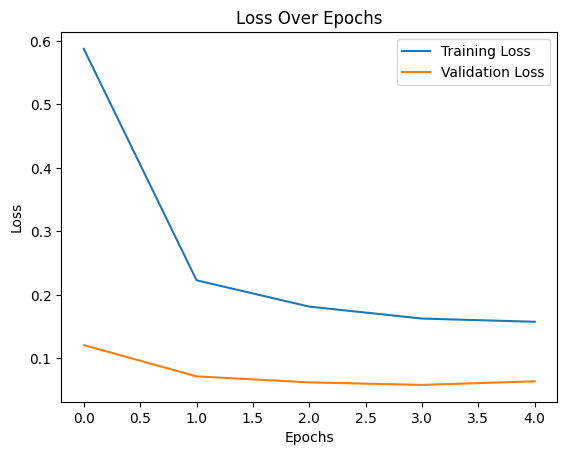

In [ ]:

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')
plt.show()

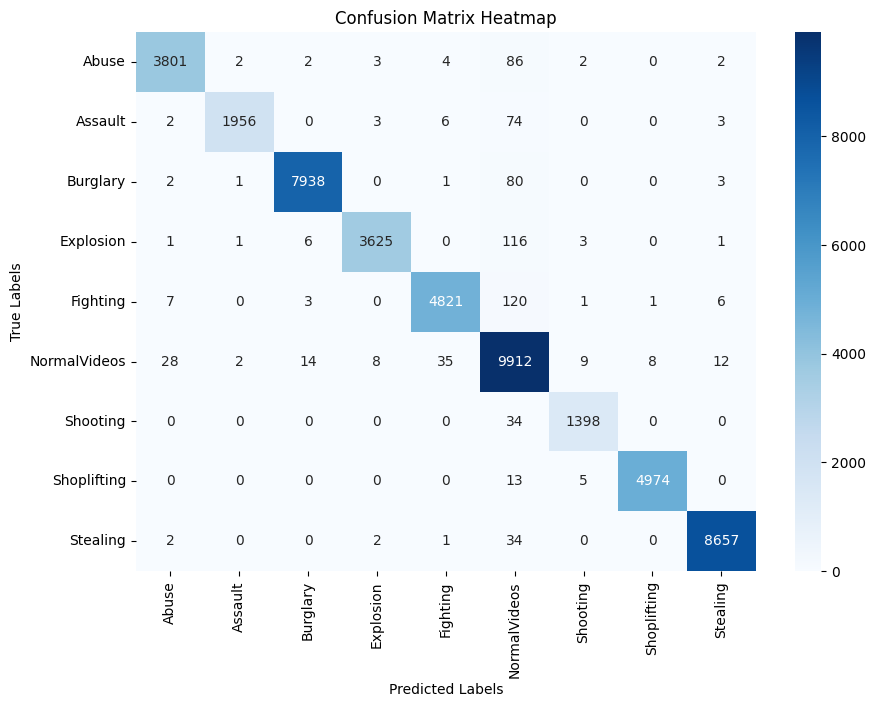

In [ ]:

conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Plot the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix Heatmap")
plt.show()


In [ ]:
model.save('/kaggle/working/my_model.h5')

In [ ]:
model.save('/kaggle/working/my_model.keras')